## Section 1: Regional & Economic Burden Distribution

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from config import CONFIG

engine = create_engine(CONFIG["db_url"])
print("Connected")

Connected


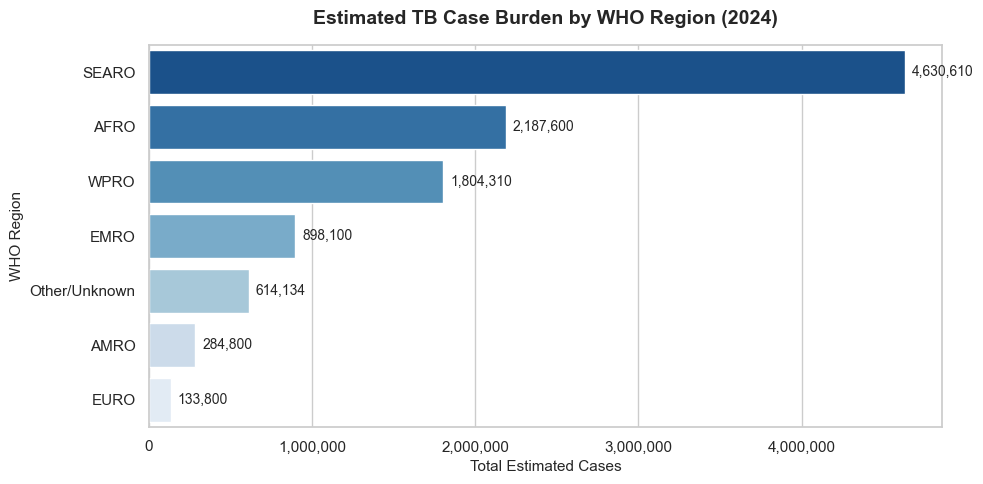

,who_region,total_countries,total_cases,avg_relative_uncertainty_pct
0,SEARO,10,4630610.0,71.50
1,AFRO,18,2187600.0,106.08
2,WPRO,11,1804310.0,63.98
3,EMRO,10,898100.0,65.99
4,Other/Unknown,114,614134.0,58.98
5,AMRO,10,284800.0,43.16
6,EURO,9,133800.0,41.24


In [5]:
# Set clean styling
sns.set_theme(style="whitegrid")

# 1. Query Regional Totals from the Base View
sql_regional = """
SELECT 
    who_region,
    COUNT(DISTINCT iso3) AS total_countries,
    ROUND(SUM(total_cases)::numeric, 0) AS total_cases,
    ROUND(AVG(ci_relative_width)::numeric, 2) AS avg_relative_uncertainty_pct
FROM vw_tb_country_totals
GROUP BY who_region
ORDER BY total_cases DESC;
"""

df_regional = pd.read_sql(sql_regional, con=engine)

# 2. Visualize Regional Burden (Updated for clean Seaborn syntax)
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_regional, 
    x="total_cases", 
    y="who_region", 
    hue="who_region",  # Set hue to match y variable
    legend=False,       # Suppress redundant legend
    palette="Blues_r"
)

# Formatting
plt.title("Estimated TB Case Burden by WHO Region (2024)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Estimated Cases", fontsize=11)
plt.ylabel("WHO Region", fontsize=11)
ax.xaxis.set_major_formatter('{x:,.0f}')

# Annotate bars with values
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.0f}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

# Display summary table
df_regional